In [19]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import pickle

In [20]:
df = pd.read_csv("homeprices_banglore.csv")

In [21]:
df.head()

,area,bedrooms,price
0,1056,2,39.07
1,2600,4,120.00
2,1440,3,62.00
3,1521,3,75.00
4,1200,2,51.00


In [22]:
X = df[['area','bedrooms']]
y = df['price']

In [23]:
sx = MinMaxScaler()
sy = MinMaxScaler()

In [24]:
X_scaled = sx.fit_transform(X)
y_scaled = sy.fit_transform(y.values.reshape(-1,1)).reshape(-1)

In [25]:
def batch_gd(X, y, epochs=2000, lr=0.01):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0
    
    for i in range(epochs):
        y_pred = np.dot(X, w) + b
        
        dw = (2/n_samples) * np.dot(X.T, (y_pred - y))
        db = (2/n_samples) * np.sum(y_pred - y)
        
        w -= lr * dw
        b -= lr * db
        
    return w, b

w, b = batch_gd(X_scaled, y_scaled)

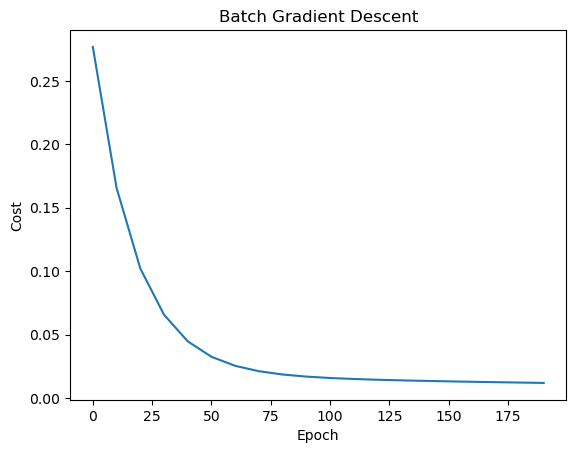

In [26]:
plt.plot(epoch_b, cost_b)
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Batch Gradient Descent")
plt.show()

In [27]:
pickle.dump(w, open("w_batch.pkl","wb"))
pickle.dump(b, open("b_batch.pkl","wb"))
pickle.dump(sx, open("sx.pkl","wb"))
pickle.dump(sy, open("sy.pkl","wb"))